In [16]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import sys
sys.path.append("../../tools")
import data
warnings.filterwarnings("ignore")

# Portfolio vs Benchmark

Compares a custom-weighted ETF portfolio against 100% AGG.  
Edit `PORTFOLIO_WEIGHTS` in the next cell â€” that is the only cell that needs to change between runs.

In [17]:
# Portfolio Weights EDIT HERE 
# Weights must sum to 1.0. Set to 0.0 to exclude an ETF.
# PORTFOLIO_WEIGHTS = {
#     "VTIP": 0.10,
#     "SHY":  0.20,
#     "IEI":  0.15,
#     "IEF":  0.10,
#     "TLH":  0.00,
#     "TLT":  0.05,
#     "VGIT": 0.20,
#     "VGLT": 0.00,
#     "TIP":  0.10,
#     "AGG":  0.10,
# }

# PORTFOLIO_NOTIONAL = 100_000   # USD â€” used for dividend $ and P&L calculations

PORTFOLIO_WEIGHTS = {
    "VTIP": 0.20,
    "SHY":  0.00,
    "IEI":  0.20,
    "IEF":  0.50,
    "TLH":  0.00,
    "TLT":  0.00,
    "VGIT": 0.10,
    "VGLT": 0.00,
    "TIP":  0.00,
    "AGG":  0.00,
}

PORTFOLIO_NOTIONAL = 15_000

LOOKBACK_YEARS = 5             # performance comparison window

In [18]:
#  ETF Metadata (same as etf_frontier.ipynb â€” refresh quarterly) 
# Sources: iShares.com, Vanguard.com, SPDR ETFs â€” last updated 2026-04-09
ETF_META = {
    "VTIP": {"name": "Vanguard Short-Term Inflation Protected Securities", "mod_duration": 0.10,  "convexity": 0.00, "expense_ratio": 0.1356},
    "SHY":  {"name": "iShares 1-3 Year Treasury",                          "mod_duration": 1.83,  "convexity": 0.05, "expense_ratio": 0.15},
    "IEI":  {"name": "iShares 3-7 Year Treasury",                          "mod_duration": 4.38,  "convexity": 0.24, "expense_ratio": 0.15},
    "IEF":  {"name": "iShares 7-10 Year Treasury",                         "mod_duration": 7.48,  "convexity": 0.69, "expense_ratio": 0.15},
    "TLH":  {"name": "iShares 10-20 Year Treasury",                        "mod_duration": 11.73, "convexity": 1.65, "expense_ratio": 0.15},
    "TLT":  {"name": "iShares 20+ Year Treasury",                          "mod_duration": 15.97, "convexity": 3.40, "expense_ratio": 0.15},
    "VGIT": {"name": "Vanguard Intermediate Treasury",                     "mod_duration": 5.30,  "convexity": 0.38, "expense_ratio": 0.04},
    "VGLT": {"name": "Vanguard Long-Term Treasury",                        "mod_duration": 13.72, "convexity": 2.44, "expense_ratio": 0.04},
    "TIP":  {"name": "iShares TIPS Bond",                                  "mod_duration": 6.84,  "convexity": 0.61, "expense_ratio": 0.19},
    "AGG":  {"name": "iShares US Aggregate (benchmark)",                   "mod_duration": 6.04,  "convexity": 0.54, "expense_ratio": 0.03},
}

TICKERS = list(ETF_META.keys())
BENCH   = "AGG"

raw = {}
for tk in TICKERS:
    hist = yf.Ticker(tk).history(period="max")
    hist.index = hist.index.tz_localize(None)
    raw[tk] = hist
    print(f"{tk}: {len(hist)} rows  {hist.index[0].date()} â†’ {hist.index[-1].date()}")

prices    = pd.DataFrame({tk: raw[tk]["Close"] for tk in TICKERS}).dropna(how="all")
daily_ret = prices.pct_change().dropna()
print(f"\nPrice matrix: {prices.shape}  ({prices.dropna().shape[0]} complete rows)")

VTIP: 3394 rows  2012-10-16 â†’ 2026-04-17
SHY: 5968 rows  2002-07-30 â†’ 2026-04-17
IEI: 4847 rows  2007-01-11 â†’ 2026-04-17
IEF: 5968 rows  2002-07-30 â†’ 2026-04-17
TLH: 4847 rows  2007-01-11 â†’ 2026-04-17
TLT: 5968 rows  2002-07-30 â†’ 2026-04-17
VGIT: 4124 rows  2009-11-23 â†’ 2026-04-17
VGLT: 4097 rows  2010-01-04 â†’ 2026-04-17
TIP: 5626 rows  2003-12-05 â†’ 2026-04-17
AGG: 5674 rows  2003-09-29 â†’ 2026-04-17

Price matrix: (5968, 10)  (3394 complete rows)


In [19]:
#  Validate weights and build arrays 
_total = sum(PORTFOLIO_WEIGHTS.values())
assert abs(_total - 1.0) < 1e-6, f"Weights sum to {_total:.6f} â€” must equal 1.0"

ACTIVE   = [tk for tk, w in PORTFOLIO_WEIGHTS.items() if w > 0]
W_ARRAY  = np.array([PORTFOLIO_WEIGHTS.get(tk, 0.0) for tk in TICKERS])

# Portfolio weighted duration and expense ratio
port_duration = sum(PORTFOLIO_WEIGHTS.get(tk, 0.0) * ETF_META[tk]["mod_duration"] for tk in TICKERS)
port_expense  = sum(PORTFOLIO_WEIGHTS.get(tk, 0.0) * ETF_META[tk]["expense_ratio"] for tk in TICKERS)
bench_dur     = ETF_META[BENCH]["mod_duration"]
bench_exp     = ETF_META[BENCH]["expense_ratio"]

print("Portfolio composition:")
for tk in ACTIVE:
    print(f"  {tk:5s}: {PORTFOLIO_WEIGHTS[tk]*100:5.1f}%  dur={ETF_META[tk]['mod_duration']:.2f}  exp={ETF_META[tk]['expense_ratio']:.4f}%")
print(f"\n  Weighted duration:       {port_duration:.2f} yrs  (vs {BENCH}: {bench_dur:.2f} yrs)")
print(f"  Weighted expense ratio:  {port_expense:.4f}%    (vs {BENCH}: {bench_exp:.4f}%)")
print(f"  Weight sum:              {_total:.4f} âœ“")

Portfolio composition:
  VTIP :  20.0%  dur=0.10  exp=0.1356%
  IEI  :  20.0%  dur=4.38  exp=0.1500%
  IEF  :  50.0%  dur=7.48  exp=0.1500%
  VGIT :  10.0%  dur=5.30  exp=0.0400%

  Weighted duration:       5.17 yrs  (vs AGG: 6.04 yrs)
  Weighted expense ratio:  0.1361%    (vs AGG: 0.0300%)
  Weight sum:              1.0000 âœ“


## Performance vs Benchmark

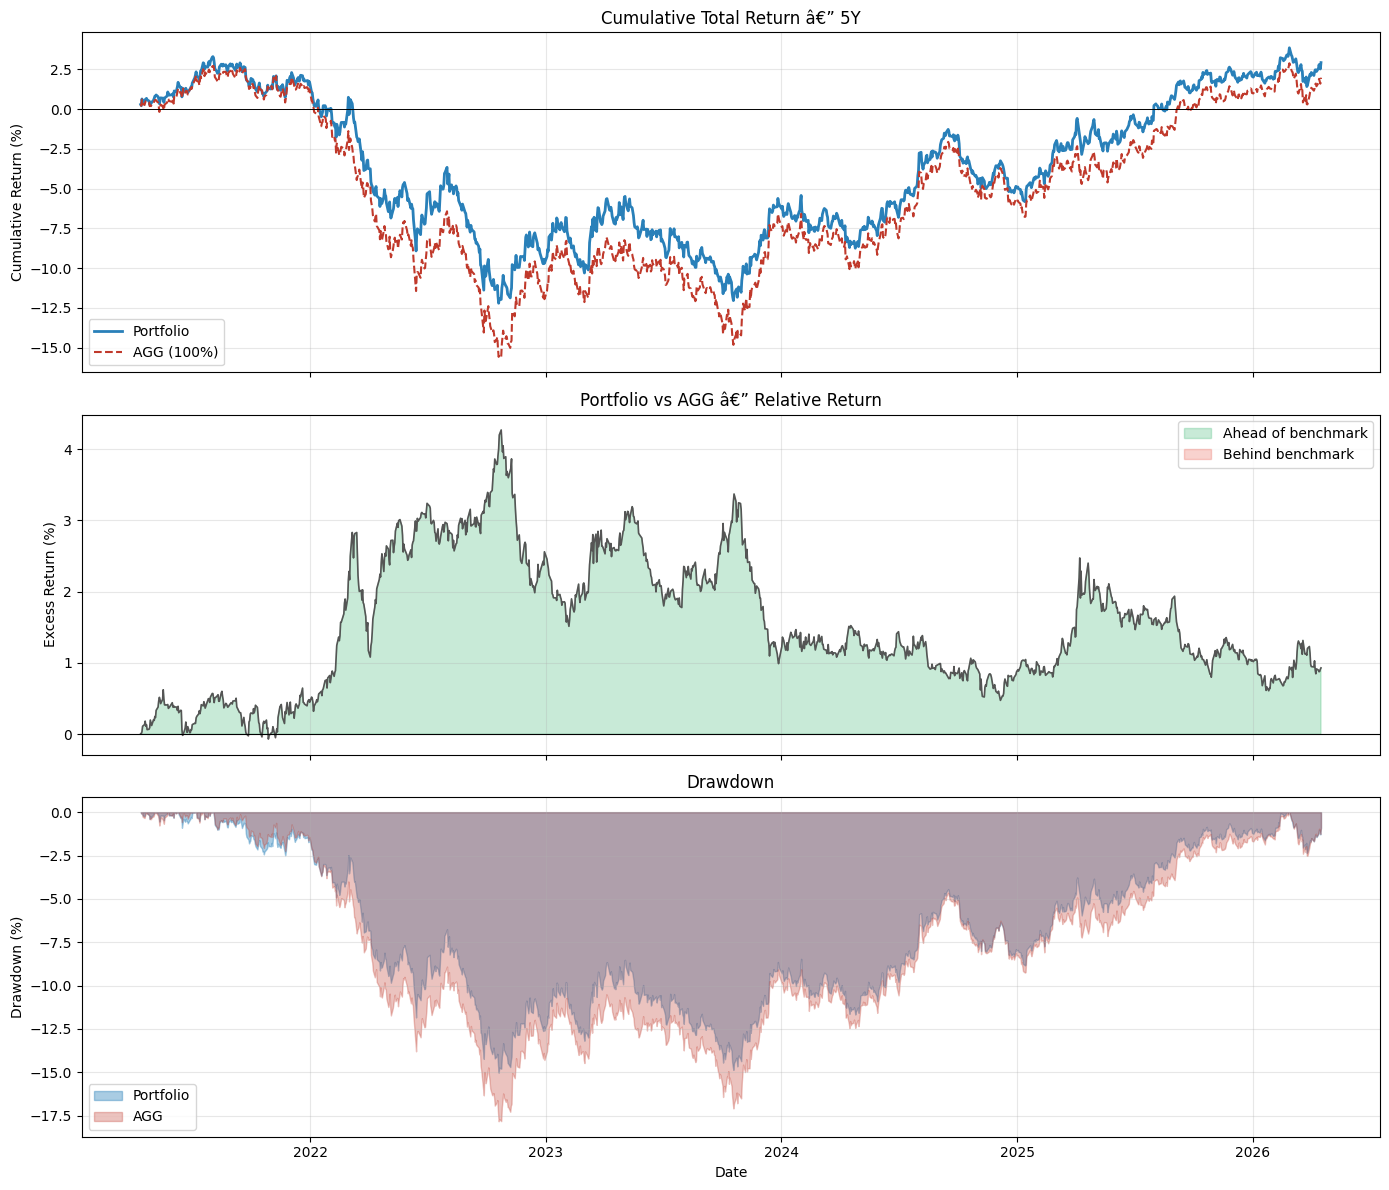

In [20]:
#  Cumulative return series 
lookback_days = LOOKBACK_YEARS * 252
ret_window    = daily_ret.tail(lookback_days).copy()

# Daily portfolio return: weighted sum across all ETFs (assumes daily rebalancing)
port_daily  = ret_window[TICKERS].fillna(0).mul(W_ARRAY).sum(axis=1)
bench_daily = ret_window[BENCH]

port_cum    = (1 + port_daily).cumprod()
bench_cum   = (1 + bench_daily).cumprod()

# Relative: how far ahead or behind benchmark (in % terms)
relative_excess = (port_cum / bench_cum - 1) * 100

# Drawdowns
port_dd  = (port_cum  / port_cum.cummax()  - 1) * 100
bench_dd = (bench_cum / bench_cum.cummax() - 1) * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Cumulative total return
ax = axes[0]
ax.plot(port_cum.index,  (port_cum  - 1) * 100, label="Portfolio",        linewidth=2,   color="#2980b9")
ax.plot(bench_cum.index, (bench_cum - 1) * 100, label=f"{BENCH} (100%)", linewidth=1.5, color="#c0392b", linestyle="--")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title(f"Cumulative Total Return â€” {LOOKBACK_YEARS}Y")
ax.set_ylabel("Cumulative Return (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Relative outperformance
ax = axes[1]
ax.plot(relative_excess.index, relative_excess, color="#555555", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.fill_between(relative_excess.index, relative_excess, 0,
                where=(relative_excess >= 0), alpha=0.25, color="#27ae60", label="Ahead of benchmark")
ax.fill_between(relative_excess.index, relative_excess, 0,
                where=(relative_excess < 0),  alpha=0.25, color="#e74c3c", label="Behind benchmark")
ax.set_title(f"Portfolio vs {BENCH} â€” Relative Return")
ax.set_ylabel("Excess Return (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Drawdown
ax = axes[2]
ax.fill_between(port_dd.index,  port_dd,  alpha=0.4, color="#2980b9", label="Portfolio")
ax.fill_between(bench_dd.index, bench_dd, alpha=0.3, color="#c0392b", label=f"{BENCH}")
ax.set_title("Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
#  Performance summary 
def _ann_ret(r):  return (1 + r).prod() ** (252 / len(r)) - 1
def _ann_vol(r):  return r.std() * np.sqrt(252)
def _max_dd(cum): return (cum / cum.cummax() - 1).min()
def _sharpe(r):   return _ann_ret(r) / _ann_vol(r) if _ann_vol(r) > 0 else np.nan

port_total  = port_cum.iloc[-1]  - 1
bench_total = bench_cum.iloc[-1] - 1

p_ann  = _ann_ret(port_daily);   b_ann  = _ann_ret(bench_daily)
p_vol  = _ann_vol(port_daily);   b_vol  = _ann_vol(bench_daily)
p_sh   = _sharpe(port_daily);    b_sh   = _sharpe(bench_daily)
p_dd   = _max_dd(port_cum);      b_dd   = _max_dd(bench_cum)
p_cal  = p_ann / abs(p_dd) if p_dd != 0 else np.nan
b_cal  = b_ann / abs(b_dd) if b_dd != 0 else np.nan

df_perf = pd.DataFrame([
    ("Total Return",    f"{port_total*100:+.2f}%",   f"{bench_total*100:+.2f}%",   f"{(port_total-bench_total)*100:+.2f}%"),
    ("Ann. Return",     f"{p_ann*100:+.2f}%",        f"{b_ann*100:+.2f}%",         f"{(p_ann-b_ann)*100:+.2f}%"),
    ("Ann. Volatility", f"{p_vol*100:.2f}%",         f"{b_vol*100:.2f}%",          f"{(p_vol-b_vol)*100:+.2f}%"),
    ("Sharpe Ratio",    f"{p_sh:.3f}",               f"{b_sh:.3f}",                f"{p_sh-b_sh:+.3f}"),
    ("Max Drawdown",    f"{p_dd*100:.2f}%",          f"{b_dd*100:.2f}%",           f"{(p_dd-b_dd)*100:+.2f}%"),
    ("Calmar Ratio",    f"{p_cal:.3f}",              f"{b_cal:.3f}",               f"{p_cal-b_cal:+.3f}"),
    ("Mod Duration",    f"{port_duration:.2f} yrs",  f"{bench_dur:.2f} yrs",       f"{port_duration-bench_dur:+.2f} yrs"),
    ("Expense Ratio",   f"{port_expense:.4f}%",      f"{bench_exp:.4f}%",          f"{port_expense-bench_exp:+.4f}%"),
], columns=["Metric", "Portfolio", f"{BENCH} (benchmark)", "Delta (Port âˆ’ Bench)"])

print(f"=== {LOOKBACK_YEARS}Y Performance: Portfolio vs {BENCH} ===")
print(df_perf.to_string(index=False))
print()

# Dollar P&L
port_pnl  = PORTFOLIO_NOTIONAL * port_total
bench_pnl = PORTFOLIO_NOTIONAL * bench_total
delta_pnl = port_pnl - bench_pnl
direction = "outperformed" if delta_pnl > 0 else "underperformed"

print(f"=== Dollar P&L on ${PORTFOLIO_NOTIONAL:,.0f} notional ===")
print(f"  Portfolio gain:  ${port_pnl:>+10,.2f}")
print(f"  Benchmark gain:  ${bench_pnl:>+10,.2f}")
print(f"  Difference:      ${delta_pnl:>+10,.2f}  ({direction} by ${abs(delta_pnl):,.2f})")

=== 5Y Performance: Portfolio vs AGG ===
         Metric Portfolio AGG (benchmark) Delta (Port âˆ’ Bench)
   Total Return    +2.93%          +1.98%                 +0.95%
    Ann. Return    +0.58%          +0.39%                 +0.19%
Ann. Volatility     5.68%           6.06%                 -0.38%
   Sharpe Ratio     0.102           0.065                 +0.037
   Max Drawdown   -15.02%         -17.82%                 +2.80%
   Calmar Ratio     0.039           0.022                 +0.017
   Mod Duration  5.17 yrs        6.04 yrs              -0.87 yrs
  Expense Ratio   0.1361%         0.0300%               +0.1061%

=== Dollar P&L on $15,000 notional ===
  Portfolio gain:  $   +439.17
  Benchmark gain:  $   +296.79
  Difference:      $   +142.38  (outperformed by $142.38)


=== Calendar Year Returns (%) ===
      Portfolio    AGG  Delta
Date                         
2021       1.68   1.22   0.45
2022     -11.19 -13.02   1.83
2023       4.10   5.66  -1.56
2024       1.14   1.31  -0.17
2025       7.37   7.19   0.18
2026       0.84   0.95  -0.11


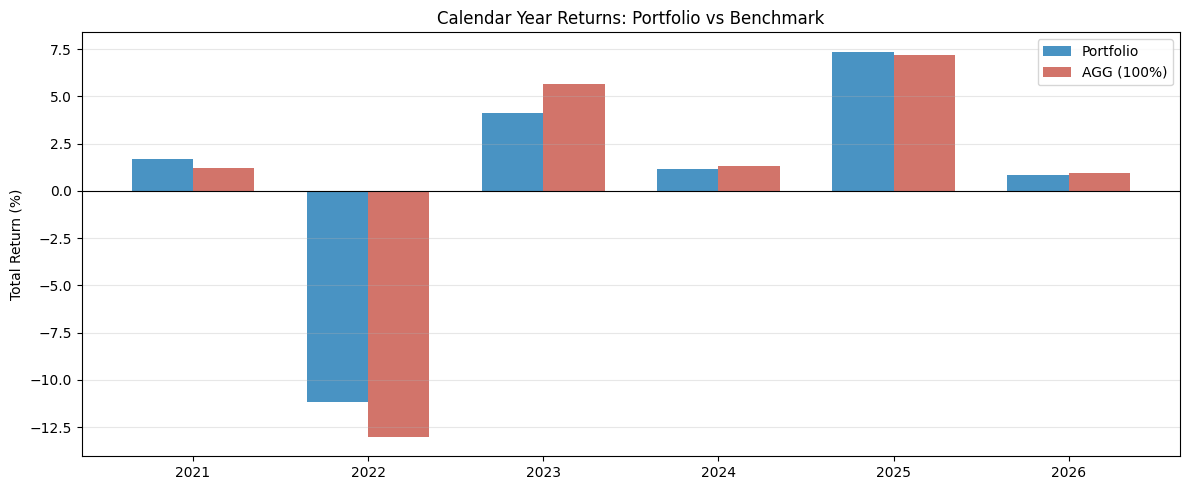

In [22]:
#  Calendar year returns 
# Annual total return for portfolio and benchmark, side-by-side
combined = pd.DataFrame({"Portfolio": port_daily, BENCH: bench_daily})
cal_ret  = combined.groupby(combined.index.year).apply(
    lambda g: (1 + g).prod() - 1
) * 100
cal_ret["Delta"] = cal_ret["Portfolio"] - cal_ret[BENCH]

print("=== Calendar Year Returns (%) ===")
print(cal_ret.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(cal_ret))
width  = 0.35
bars_p = ax.bar(x - width/2, cal_ret["Portfolio"], width, label="Portfolio",       color="#2980b9", alpha=0.85)
bars_b = ax.bar(x + width/2, cal_ret[BENCH],        width, label=f"{BENCH} (100%)", color="#c0392b", alpha=0.70)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cal_ret.index)
ax.set_ylabel("Total Return (%)")
ax.set_title("Calendar Year Returns: Portfolio vs Benchmark")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Dividends Received

In [23]:
#  TTM dividends: portfolio vs benchmark 
# Shares held = (weight Ã— notional) / current price
# TTM dividends = shares Ã— sum of dividends paid in last 252 trading days
div_rows = []
for tk in TICKERS:
    w          = PORTFOLIO_WEIGHTS.get(tk, 0.0)
    cur_price  = raw[tk]["Close"].iloc[-1]
    allocated  = w * PORTFOLIO_NOTIONAL
    shares     = allocated / cur_price
    ttm_div_ps = raw[tk]["Dividends"].tail(252).sum()  # per share
    ttm_div    = shares * ttm_div_ps                   # total $
    div_yield  = (ttm_div_ps / cur_price) * 100
    net_carry  = div_yield - ETF_META[tk]["expense_ratio"]

    div_rows.append({
        "Ticker":           tk,
        "Weight":           w,
        "$ Allocated":      round(allocated, 2),
        "Price":            round(cur_price, 2),
        "Shares":           round(shares, 4),
        "Div/Share (TTM)": round(ttm_div_ps, 4),
        "Div Yield %":      round(div_yield, 3),
        "Net Carry %":      round(net_carry, 3),
        "$ Div (TTM)":      round(ttm_div, 2),
    })

df_div = pd.DataFrame(div_rows)

# Benchmark totals (100% AGG)
agg_price       = raw[BENCH]["Close"].iloc[-1]
agg_shares      = PORTFOLIO_NOTIONAL / agg_price
agg_div_ps      = raw[BENCH]["Dividends"].tail(252).sum()
total_div_bench = agg_shares * agg_div_ps
total_div_port  = df_div["$ Div (TTM)"].sum()
div_delta       = total_div_port - total_div_bench

# Print active ETFs only
df_div_active = df_div[df_div["Weight"] > 0].copy()
df_div_active["Weight"] = df_div_active["Weight"].map(lambda x: f"{x*100:.1f}%")

print(f"=== Dividends (TTM) on ${PORTFOLIO_NOTIONAL:,.0f} notional ===")
print()
print(df_div_active.to_string(index=False))
print()
print(f"  Portfolio TTM dividends:  ${total_div_port:>10,.2f}")
print(f"  Benchmark TTM dividends:  ${total_div_bench:>10,.2f}")
print(f"  Difference:               ${div_delta:>+10,.2f}  ({'more' if div_delta > 0 else 'less'} income vs {BENCH})")

=== Dividends (TTM) on $15,000 notional ===

Ticker Weight  $ Allocated  Price  Shares  Div/Share (TTM)  Div Yield %  Net Carry %  $ Div (TTM)
  VTIP  20.0%       3000.0  50.16 59.8086            1.808        3.604        3.469       108.13
   IEI  20.0%       3000.0 119.02 25.2058            4.231        3.555        3.405       106.65
   IEF  50.0%       7500.0  95.93 78.1820            3.660        3.815        3.665       286.15
  VGIT  10.0%       1500.0  59.76 25.1004            2.272        3.802        3.762        57.03

  Portfolio TTM dividends:  $    557.96
  Benchmark TTM dividends:  $    587.38
  Difference:               $    -29.42  (less income vs AGG)


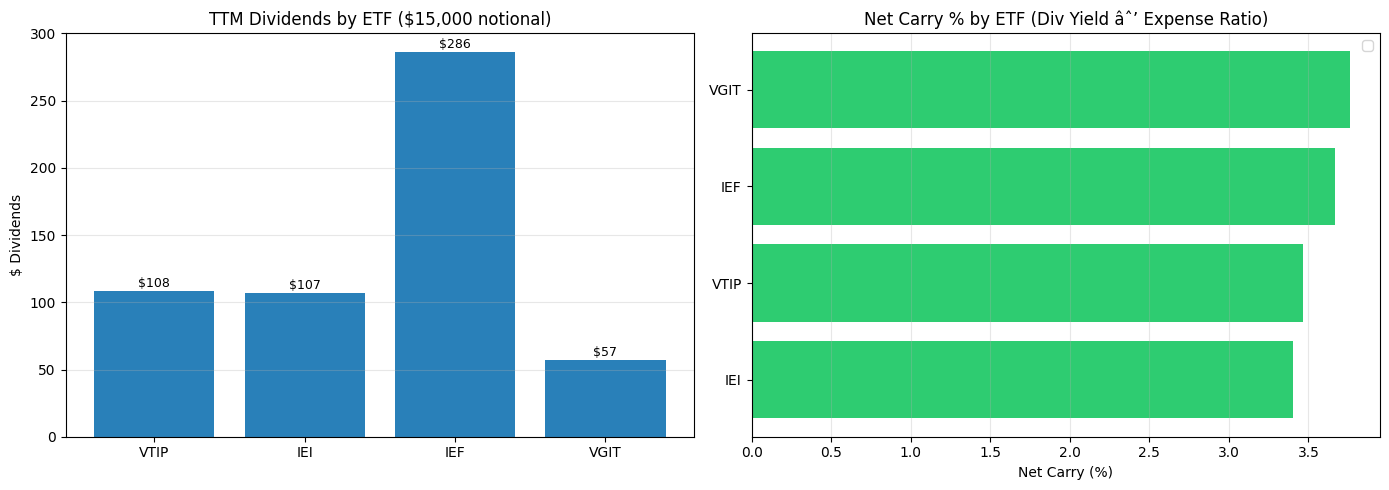

In [24]:
#  Dividend charts 
active_div = df_div[df_div["Weight"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: $ dividends by ETF
ax = axes[0]
colors = ["#c0392b" if tk == BENCH else "#2980b9" for tk in active_div["Ticker"]]
bars   = ax.bar(active_div["Ticker"], active_div["$ Div (TTM)"], color=colors)
ax.axhline(0, color="black", linewidth=0.5)
for bar, val in zip(bars, active_div["$ Div (TTM)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title(f"TTM Dividends by ETF (${PORTFOLIO_NOTIONAL:,.0f} notional)")
ax.set_ylabel("$ Dividends")
ax.grid(True, alpha=0.3, axis="y")

# Right: net carry % vs benchmark
ax = axes[1]
bench_nc = active_div.loc[active_div["Ticker"] == BENCH, "Net Carry %"].values
sorted_div = active_div.sort_values("Net Carry %", ascending=True)
bar_colors = ["#c0392b" if tk == BENCH else "#2ecc71" for tk in sorted_div["Ticker"]]
ax.barh(sorted_div["Ticker"], sorted_div["Net Carry %"], color=bar_colors)
if len(bench_nc):
    ax.axvline(bench_nc[0], color="red", linestyle="--", linewidth=1.5,
               label=f"{BENCH} net carry: {bench_nc[0]:.2f}%")
ax.set_title("Net Carry % by ETF (Div Yield âˆ’ Expense Ratio)")
ax.set_xlabel("Net Carry (%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## Key Rate Durations

Empirical OLS: regress each ETF's daily returns on simultaneous daily changes at four rate tenors (2Y, 5Y, 10Y, 30Y).  
`KRD_k = âˆ’Î²_k Ã— 100`” how many years of duration the portfolio has at each point on the curve.

Portfolio weighted KRD = Î£ (weight Ã— ETF KRD) per tenor.  
Benchmark (AGG) KRD shown as reference bars.

Fitting KRD regressions (OLS)...
  VTIP   2Y=-1.48  5Y=5.12  10Y=-2.80  30Y=-0.62  total=0.22  R²=0.355
  IEI    2Y=3.26  5Y=-1.11  10Y=3.41  30Y=-0.58  total=4.97  R²=0.950
  IEF    2Y=3.47  5Y=-2.73  10Y=7.64  30Y=-0.66  total=7.72  R²=0.931
  VGIT   2Y=2.76  5Y=-1.23  10Y=4.73  30Y=-1.15  total=5.11  R²=0.957
  AGG    2Y=4.77  5Y=-6.43  10Y=8.16  30Y=0.93  total=7.43  R²=0.942

KRD table:
         Ticker  Weight     2Y     5Y    10Y    30Y  Total Duration    R²
           VTIP     0.2 -1.484  5.120 -2.803 -0.615           0.217 0.355
            IEI     0.2  3.255 -1.109  3.410 -0.584           4.973 0.950
            IEF     0.5  3.470 -2.731  7.636 -0.658           7.717 0.931
           VGIT     0.1  2.760 -1.231  4.729 -1.145           5.112 0.957
            AGG     0.0  4.766 -6.427  8.161  0.931           7.430 0.942
Portfolio (wtd)     1.0  2.365 -0.687  4.412 -0.683           5.408   NaN


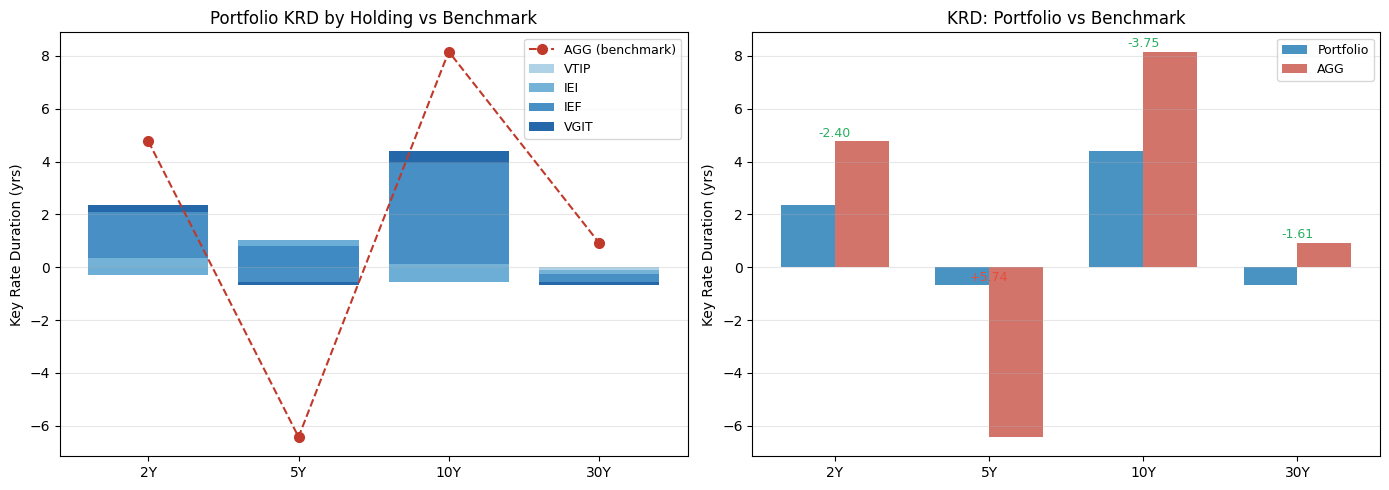

In [25]:
from pathlib import Path as _Path
import sys as _sys
_ROOT = _Path("../..").resolve()
if str(_ROOT) not in _sys.path:
    _sys.path.insert(0, str(_ROOT))

from tools.securities import FI_ETF

KRD_TENORS = ("DGS2", "DGS5", "DGS10", "DGS30")
KRD_LABELS = {"DGS2": "2Y", "DGS5": "5Y", "DGS10": "10Y", "DGS30": "30Y"}

# ── Fit KRD for each active ETF + benchmark ───────────────────────────────────
print("Fitting KRD regressions (OLS)...")
krd_raw = {}   # ticker → pd.Series

all_tickers = ACTIVE + ([BENCH] if BENCH not in ACTIVE else [])
for tk in all_tickers:
    etf = FI_ETF(tk)
    krd = etf.key_rate_durations(*KRD_TENORS)
    krd_raw[tk] = krd
    tenors_str = "  ".join(f"{KRD_LABELS[t]}={krd[t]:.2f}" for t in KRD_TENORS)
    print(f"  {tk:5s}  {tenors_str}  total={krd['total_duration']:.2f}  R²={krd['r_squared']:.3f}")

# ── Portfolio-weighted KRD ────────────────────────────────────────────────────
port_krd = pd.Series(0.0, index=list(KRD_TENORS))
for tk in ACTIVE:
    w = PORTFOLIO_WEIGHTS[tk]
    for t in KRD_TENORS:
        port_krd[t] += w * krd_raw[tk][t]

bench_krd = pd.Series({t: krd_raw[BENCH][t] for t in KRD_TENORS})
port_krd.name  = "Portfolio"
bench_krd.name = BENCH

# ── KRD table ─────────────────────────────────────────────────────────────────
krd_rows = []
for tk in all_tickers:
    row = {"Ticker": tk, "Weight": PORTFOLIO_WEIGHTS.get(tk, 1.0 if tk == BENCH else 0.0)}
    for t in KRD_TENORS:
        row[KRD_LABELS[t]] = round(krd_raw[tk][t], 3)
    row["Total Duration"] = round(krd_raw[tk]["total_duration"], 3)
    row["R²"]             = round(krd_raw[tk]["r_squared"], 3)
    krd_rows.append(row)

# Add weighted portfolio row
port_row = {"Ticker": "Portfolio (wtd)", "Weight": 1.0}
for t in KRD_TENORS:
    port_row[KRD_LABELS[t]] = round(port_krd[t], 3)
port_row["Total Duration"] = round(port_krd.sum(), 3)
port_row["R²"] = None
krd_rows.append(port_row)

df_krd = pd.DataFrame(krd_rows)
print("\nKRD table:")
print(df_krd.to_string(index=False))

# ── Chart: stacked bar portfolio vs benchmark per tenor ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tenor_labels = [KRD_LABELS[t] for t in KRD_TENORS]

# Left: per-holding contribution stacked
ax = axes[0]
colors_stk = plt.cm.Blues(np.linspace(0.35, 0.85, len(ACTIVE)))
bottoms = np.zeros(len(KRD_TENORS))
for i, tk in enumerate(ACTIVE):
    contrib = np.array([PORTFOLIO_WEIGHTS[tk] * krd_raw[tk][t] for t in KRD_TENORS])
    ax.bar(tenor_labels, contrib, bottom=bottoms, label=tk, color=colors_stk[i], alpha=0.9)
    bottoms += contrib
ax.plot(tenor_labels, bench_krd.values, "o--", color="#c0392b",
        linewidth=1.5, markersize=7, label=f"{BENCH} (benchmark)")
ax.set_title("Portfolio KRD by Holding vs Benchmark")
ax.set_ylabel("Key Rate Duration (yrs)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# Right: portfolio vs benchmark side-by-side per tenor
ax2 = axes[1]
x = np.arange(len(KRD_TENORS))
w = 0.35
ax2.bar(x - w/2, port_krd.values, w, label="Portfolio", color="#2980b9", alpha=0.85)
ax2.bar(x + w/2, bench_krd.values, w, label=f"{BENCH}", color="#c0392b", alpha=0.70)
ax2.set_xticks(x)
ax2.set_xticklabels(tenor_labels)
ax2.set_title("KRD: Portfolio vs Benchmark")
ax2.set_ylabel("Key Rate Duration (yrs)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")
# Delta annotations
for i, (pv, bv) in enumerate(zip(port_krd.values, bench_krd.values)):
    delta = pv - bv
    y_pos = max(pv, bv) + 0.05
    color = "#27ae60" if delta < 0 else "#e74c3c"
    ax2.text(i, y_pos, f"{delta:+.2f}", ha="center", va="bottom", fontsize=9, color=color)

plt.tight_layout()
plt.savefig(
    _Path("../..").resolve() / "models" / "treasuries_spring26" / "output" / "krd_profile.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

## Excel Export

In [26]:
from tools.excel import NotebookWorkbook

OUT_PATH = data.PROJECT_ROOT / "models" / "treasuries_spring26" / "output" / "portfolio_vs_benchmark.xlsx"
wb = NotebookWorkbook(OUT_PATH)

# ── Sheet 1: Portfolio weights ────────────────────────────────────────────────
df_weights = pd.DataFrame([
    {
        "Ticker":        tk,
        "Name":          ETF_META[tk]["name"],
        "Weight":        PORTFOLIO_WEIGHTS.get(tk, 0.0),
        "Mod Duration":  ETF_META[tk]["mod_duration"],
        "Expense Ratio": ETF_META[tk]["expense_ratio"],
        "Wtd Duration":  round(PORTFOLIO_WEIGHTS.get(tk, 0.0) * ETF_META[tk]["mod_duration"], 4),
        "Wtd Expense":   round(PORTFOLIO_WEIGHTS.get(tk, 0.0) * ETF_META[tk]["expense_ratio"], 6),
    }
    for tk in TICKERS
])
wb.write("Portfolio Weights", df_weights)

# ── Sheet 2: Performance summary ─────────────────────────────────────────────
wb.write("Performance Summary", df_perf)

# ── Sheet 3: Calendar year returns ───────────────────────────────────────────
wb.write("Calendar Year Returns", cal_ret.round(4).reset_index().rename(columns={"index": "Year"}))

# ── Sheet 4: Dividend detail ──────────────────────────────────────────────────
df_div_export = df_div.copy()
df_div_export["Weight"] = df_div_export["Weight"].map(lambda x: f"{x*100:.1f}%")
wb.write("Dividend Detail", df_div_export)

# ── Sheet 5: Cumulative returns time series ────────────────────────────────────
df_cum = pd.DataFrame({
    "Portfolio_cum_ret": (port_cum - 1) * 100,
    f"{BENCH}_cum_ret":  (bench_cum - 1) * 100,
    "Relative_excess":   relative_excess,
    "Port_drawdown":     port_dd,
    f"{BENCH}_drawdown": bench_dd,
})
df_cum.index.name = "Date"
wb.write("Cumulative Returns", df_cum.reset_index())

# ── Sheet 6: Key Rate Durations ───────────────────────────────────────────────
wb.write("Key Rate Durations", df_krd)

path = wb.save()
print(f"Saved → {path}")

Saved → C:\Users\btm74.000\Projects\qf_toolset\models\treasuries_spring26\output\portfolio_vs_benchmark.xlsx
